# Exercise 1 — Demand Response Control (Effacement de Consommation)
## Internship — Energy Market & Portfolio Management — Agregio Solutions

**Objective:** Perform the post-activation control (*contrôle du réalisé*) for an industrial demand response event that occurred on 24/01/2024.

**Steps:**
1. Compute the reference consumption curve using the *Médiane 10J* method
2. Determine the curtailed energy volume per 10-minute timestep
3. Compute the client's total remuneration and any penalties
4. Produce a summary chart showing reference, actual consumption, and setpoint

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%matplotlib inline


## 1. Imports and Data Loading

### Loading the consumption curve
The file contains the client's power draw (kW) at 10-minute intervals for all of January 2024.

- `sep=";"` : the CSV uses semicolons as delimiters (standard French format)
- `dayfirst=True` : dates are in DD/MM/YYYY format (French convention)

In [16]:
df = pd.read_csv(
    "Consommation_Client_Janvier2024.csv",
    sep=";",
    parse_dates=["Horodate"],
    dayfirst=True
)

print(f"Date range: {df['Horodate'].min()} -> {df['Horodate'].max()}")
print(f"Number of data points: {len(df)}")
df.head()

Date range: 2024-01-01 00:00:00 -> 2024-01-31 23:50:00
Number of data points: 4464


,Horodate,P Soutiree (kW)
0,2024-01-01 00:00:00,159865
1,2024-01-01 00:10:00,158913
2,2024-01-01 00:20:00,160092
3,2024-01-01 00:30:00,161405
4,2024-01-01 00:40:00,158769


### Loading the activation parameters

In [17]:
params = pd.read_csv("Parametres.csv", sep=";")
params

,Client,Debut,Fin,Puissance_consigne_MW,Prix_offre_eur_MWh,Prix_penalites_eur_MWh
0,Client A,24/01/2024 09:00,24/01/2024 11:00,50,350,250


In [18]:
#Extract parameters into individual variables
activation_start = pd.to_datetime(params["Debut"].iloc[0], dayfirst=True)
activation_end   = pd.to_datetime(params["Fin"].iloc[0], dayfirst=True)
consigne_MW      = params["Puissance_consigne_MW"].iloc[0]       # 50 MW
prix_offre       = params["Prix_offre_eur_MWh"].iloc[0]          #350 EURO/MWh
prix_penalites   = params["Prix_penalites_eur_MWh"].iloc[0]      #250 EURO/MWh

print(f"Activation start:  {activation_start}")
print(f"Activation end:    {activation_end}")
print(f"Offer price:       {prix_offre} EUR/MWh")
print(f"prix_penalties:    {prix_penalites} EUR/MWh")



Activation start:  2024-01-24 09:00:00
Activation end:    2024-01-24 11:00:00
Offer price:       350 EUR/MWh
prix_penalties:    250 EUR/MWh


---
## 2. Computing the Reference Curve — *Médiane 10J* Method

The reference represents the **theoretical consumption** the site would have had without the demand response activation.

**RTE's method:**
1. Select the 10 most recent business days before day J (excluding weekends and public holidays)
2. For each 10-minute time slot (HH:MM), compute the **median** of the 10 observed power values

**Why median instead of mean?**  
The median is robust to outliers. If the site had a maintenance shutdown or an anomalous spike on one of the 10 days, the mean would be distorted — the median would not.

In [19]:
activation_date = activation_start.date()   #2024-01-24


#French public holidays in January 2024
jours_feries = [pd.Timestamp("2024-01-01")]    #New Year's Day


#Extract all unique dates from the dataset
df["date"] = df["Horodate"].dt.date
all_dates = pd.Series(sorted(df["date"].unique()))

#Filter: days before Jan 24, weekdays only (Mon-Fri), excluding public holidays
candidate_days = all_dates[all_dates < activation_date]
business_days = [
    d for d in candidate_days
    if pd.Timestamp(d).weekday() < 5           # Monday(0) to Friday(4)
    and pd.Timestamp(d) not in jours_feries    # Exclude Jan 1st  
]


#Take the 10 most recent business days
ref_days = sorted(business_days) [-10:]
print("The 10 reference business days:")
for d in ref_days:
    print(f"  {d} - {pd.Timestamp(d).strftime('%A')}")


The 10 reference business days:
  2024-01-10 - Wednesday
  2024-01-11 - Thursday
  2024-01-12 - Friday
  2024-01-15 - Monday
  2024-01-16 - Tuesday
  2024-01-17 - Wednesday
  2024-01-18 - Thursday
  2024-01-19 - Friday
  2024-01-22 - Monday
  2024-01-23 - Tuesday


### Computing the median per time slot

For each HH:MM timestamp (e.g. 09:00, 09:10...), we take the 10 corresponding power values from the 10 reference days and compute their median.

In [20]:
# Filter data to the 10 reference days only
df_ref = df[df["date"].isin(ref_days)].copy()

# Add a HH:MM column for grouping by time slot
df_ref["time"] = df_ref["Horodate"].dt.strftime("%H:%M")

#Median per time slot
reference = df_ref.groupby("time")["P Soutiree (kW)"].median()
reference.name = "P_reference_kW"


#Display reference values over the activation window
print("Reference (Médiane 10J) over the 9:00-11:00 windows:")
for t in ["09:00","09:10","09:20","09:30","09:40","09:50",
          "10:00","10:10","10:20","10:30","10:40","10:50"]:
    print(f"    {t} → {reference[t]/1000:.1f} MW")


Reference (Médiane 10J) over the 9:00-11:00 windows:
    09:00 → 199.8 MW
    09:10 → 199.9 MW
    09:20 → 200.0 MW
    09:30 → 200.2 MW
    09:40 → 199.0 MW
    09:50 → 200.7 MW
    10:00 → 199.5 MW
    10:10 → 200.4 MW
    10:20 → 199.5 MW
    10:30 → 200.1 MW
    10:40 → 199.3 MW
    10:50 → 201.0 MW


---
## 3. Activation Period Analysis

We now compare the **actual consumption** on 24/01 with the **reference** over the 09:00–11:00 window.

- **Curtailed volume** = Reference − Actual consumption (what the client effectively reduced)
- **Expected volume** = Setpoint × duration (what RTE expected)
- Power → energy conversion: each 10-min step = 10/60 = 1/6 hour

In [21]:
# Filtre the activation period: 9:00 to 10:50 inclusive (11:00 excluded)
mask_activation = (
    (df["Horodate"] >= activation_start) &
    (df["Horodate"] < activation_end)
)
df_activation = df[mask_activation].copy()

print(f":Number of 10-min timesteps: {len(df_activation)}")
print(f"From {df_activation['Horodate'].iloc[0]} to {df_activation['Horodate'].iloc[-1]}")



:Number of 10-min timesteps: 12
From 2024-01-24 09:00:00 to 2024-01-24 10:50:00


In [22]:
df_activation

,Horodate,P Soutiree (kW),date
3366,2024-01-24 09:00:00,151567,2024-01-24
3367,2024-01-24 09:10:00,152036,2024-01-24
3368,2024-01-24 09:20:00,152528,2024-01-24
3369,2024-01-24 09:30:00,151648,2024-01-24
3370,2024-01-24 09:40:00,152482,2024-01-24
3371,2024-01-24 09:50:00,150886,2024-01-24
3372,2024-01-24 10:00:00,154159,2024-01-24
3373,2024-01-24 10:10:00,155040,2024-01-24
3374,2024-01-24 10:20:00,149466,2024-01-24
3375,2024-01-24 10:30:00,149849,2024-01-24


In [23]:
# Join reference values to the activation dataframe
df_activation["time"] = df_activation["Horodate"].dt.strftime("%H:%M")
df_activation = df_activation.merge(
    reference.reset_index(),
    on="time",
    how="left"
)

# Setpoint in kW
consigne_kW = consigne_MW * 1000 # 50 mw = 50,000 kW

#target level = reference - setpoint
df_activation["P_consigne_kW"] = df_activation["P_reference_kW"] - consigne_kW

# Curtailed power per timestep (kW)
df_activation["volume_efface_kW"] = (
    df_activation["P_reference_kW"] - df_activation["P Soutiree (kW)"]
)

#Convert to energy (MWh) : 10 min = 10/60 hours
step_hours = 10 / 60
df_activation["E_efface_MWh"] = df_activation["volume_efface_kW"] * step_hours /1000
df_activation["E_attendu_MWh"] = consigne_kW * step_hours / 1000   # 8,33 MWh per step

# Detailed table
detail = df_activation[["Horodate", "P_reference_kW", "P Soutiree (kW)",
                         "P_consigne_kW", "volume_efface_kW", "E_efface_MWh"]].copy()
 # detail.columns = ["Timestamp", "Reference (kW)", "Actual (kW)",
                  #  "Target (kW)", "Curtailed (kW)", "Curtailed (MWh)"]
detail






                                                              
                                                              
                                                              

,Horodate,P_reference_kW,P Soutiree (kW),P_consigne_kW,volume_efface_kW,E_efface_MWh
0,2024-01-24 09:00:00,199847.0,151567,149847.0,48280.0,8.046667
1,2024-01-24 09:10:00,199933.0,152036,149933.0,47897.0,7.982833
2,2024-01-24 09:20:00,200004.5,152528,150004.5,47476.5,7.912750
3,2024-01-24 09:30:00,200173.5,151648,150173.5,48525.5,8.087583
4,2024-01-24 09:40:00,199024.5,152482,149024.5,46542.5,7.757083
5,2024-01-24 09:50:00,200704.0,150886,150704.0,49818.0,8.303000
6,2024-01-24 10:00:00,199511.5,154159,149511.5,45352.5,7.558750
7,2024-01-24 10:10:00,200446.5,155040,150446.5,45406.5,7.567750
8,2024-01-24 10:20:00,199466.0,149466,149466.0,50000.0,8.333333
9,2024-01-24 10:30:00,200055.0,149849,150055.0,50206.0,8.367667


## 4. Performance Indicators

In [24]:
volume_efface_total  = df_activation["E_efface_MWh"].sum()
volume_attendu_total = df_activation["E_attendu_MWh"].sum()
taux_realisation     = (volume_efface_total / volume_attendu_total) * 100

print("=" * 50)
print("PERFORMANCE INDICATORS")
print("=" * 50)
print(f" Curtailed volume:      {volume_efface_total:.2f} MWh")
print(f" Expected volume:       {volume_attendu_total:.2f} MWh")
print(f" Realization rate:      {taux_realisation:.2f} %")
      

PERFORMANCE INDICATORS
 Curtailed volume:      96.33 MWh
 Expected volume:       100.00 MWh
 Realization rate:      96.33 %


---
## 5. Remuneration and Penalties

- **Remuneration** = Curtailed volume × Offer price
- **Penalty**: applied only if the realization rate < 80%
  - Penalty = 35% × Deficient volume × Penalty price
  - Deficient volume = Expected volume − Curtailed volume

In [25]:
#Renumeration
renumeration = volume_efface_total * prix_offre

# Check deficiency threshold (80%)
DEFICIENCY_TRESHOLD = 0.80

if taux_realisation / 100 < DEFICIENCY_TRESHOLD:
    volume_defaillant = volume_attendu_total - volume_efface_total
    penalite = 0.35 * volume_defaillant * prix_penalites
    statut = "DEFICIENT"
else:
    volume_defaillant = 0
    penalite = 0
    statut = "COMPLIANT"

print("=" * 50)
print(f"  FINANCIAL SUMMARY - Status: {statut}")
print("=" * 50)
print(f"  Renumeration:   {renumeration:>12,.2f} EUR")
print(f"  Penalty:        {penalite:>12,.2f} EUR")
print(f"  Net:            {renumeration - penalite:>12,.2f} EUR")



  FINANCIAL SUMMARY - Status: COMPLIANT
  Renumeration:      33,715.88 EUR
  Penalty:                0.00 EUR
  Net:               33,715.88 EUR


---
## 6. Summary Charts

The main chart shows three curves over the activation window:
- **Blue**: Reference curve (Médiane 10J) — theoretical consumption without demand response
- **Red**: Actual power draw — what the client actually consumed
- **Green dashed**: Setpoint level — the target level (Reference − 50 MW)
- **Shaded area**: Curtailed volume (difference between reference and actual)

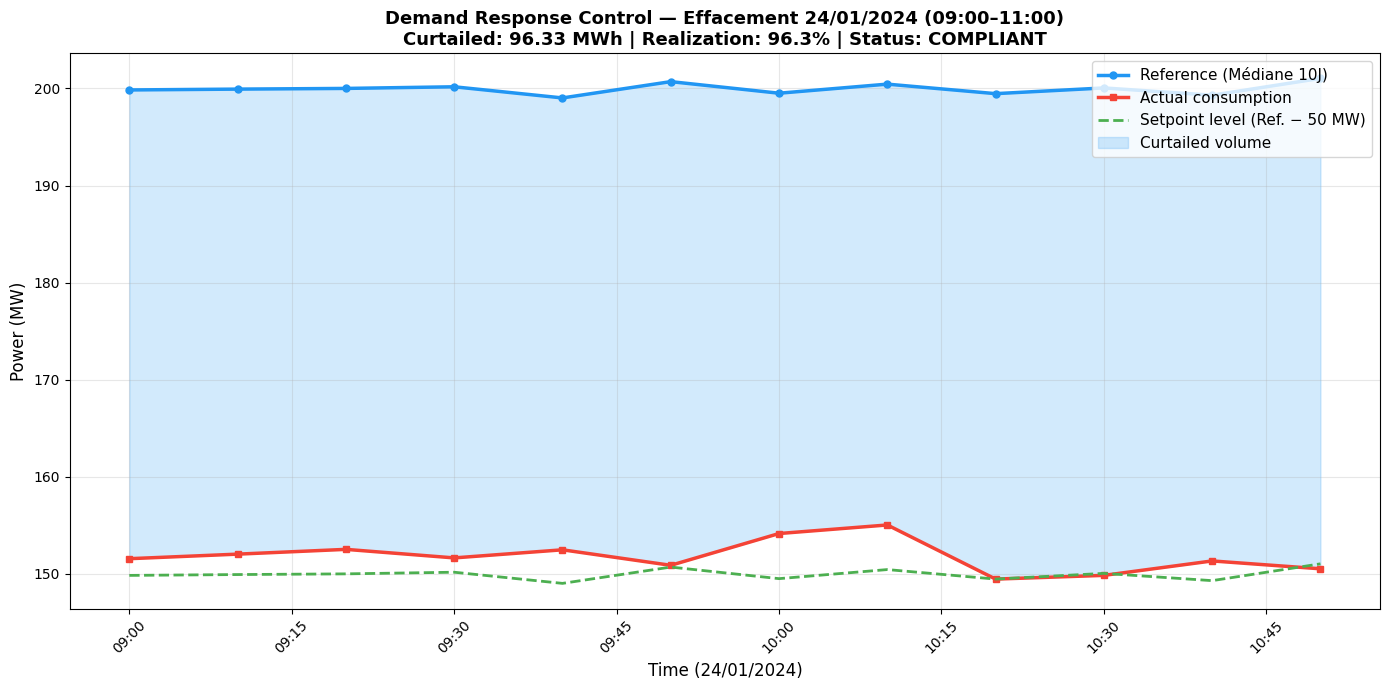

In [32]:
fig, ax = plt.subplots(figsize=(14, 7))

# Reference curve
ax.plot(
    df_activation["Horodate"],
    df_activation["P_reference_kW"] / 1000,
    color="#2196F3", linewidth=2.5, marker="o", markersize=5,
    label="Reference (Médiane 10J)", zorder=3
)

# Actual power draw
ax.plot(
    df_activation["Horodate"],
    df_activation["P Soutiree (kW)"] / 1000,
    color="#F44336", linewidth=2.5, marker="s", markersize=5,
    label="Actual consumption", zorder=3
)

# Setpoint level
ax.plot(
    df_activation["Horodate"],
    df_activation["P_consigne_kW"] / 1000,
    color="#4CAF50", linewidth=2, linestyle="--",
    label=f"Setpoint level (Ref. − {consigne_MW} MW)", zorder=3
)

# Shaded area = curtailed volume
ax.fill_between(
    df_activation["Horodate"],
    df_activation["P_reference_kW"] / 1000,
    df_activation["P Soutiree (kW)"] / 1000,
    alpha=0.2, color="#2196F3", label="Curtailed volume"
)

# Formatting
ax.set_xlabel("Time (24/01/2024)", fontsize=12)
ax.set_ylabel("Power (MW)", fontsize=12)
ax.set_title(
    f"Demand Response Control — Effacement 24/01/2024 (09:00–11:00)\n"
    f"Curtailed: {volume_efface_total:.2f} MWh | "
    f"Realization: {taux_realisation:.1f}% | "
    f"Status: {statut}",
    fontsize=13, fontweight="bold"
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(loc="upper right", fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot1_DemandResponse.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Summary Charts

The chart shows what happened on January 24th between 09:00 and 10:50.

- **Blue line (Reference - Médiane 10J)** — the normal consumption of the factory, calculated as the median of the 10 reference business days. It stays constant at ~200 MW. This is what the factory would have consumed without the demand response event.
- **Red line (Actual consumption)** — what the factory actually consumed on January 24th. It drops to ~150-155 MW, showing that the client did reduce its consumption.
- **Green dashed line (Setpoint level - Ref. − 50 MW)** — the target level: reference minus the 50 MW curtailment order. Ideally, the red line should be on or below this line.
- **Light blue shaded area (Curtailed volume)** — the gap between the reference and actual consumption. This visually represents the energy that was curtailed.

**Key observation:** the red line is slightly above the green line in the first half (09:00–10:10), meaning the client curtailed slightly less than requested. In the second half (10:20–10:50), the red line drops below the green line, meaning the client over-delivered. Overall, it balances out to a 96.3% realization rate — well above the 80% threshold, so the curtailment is compliant.

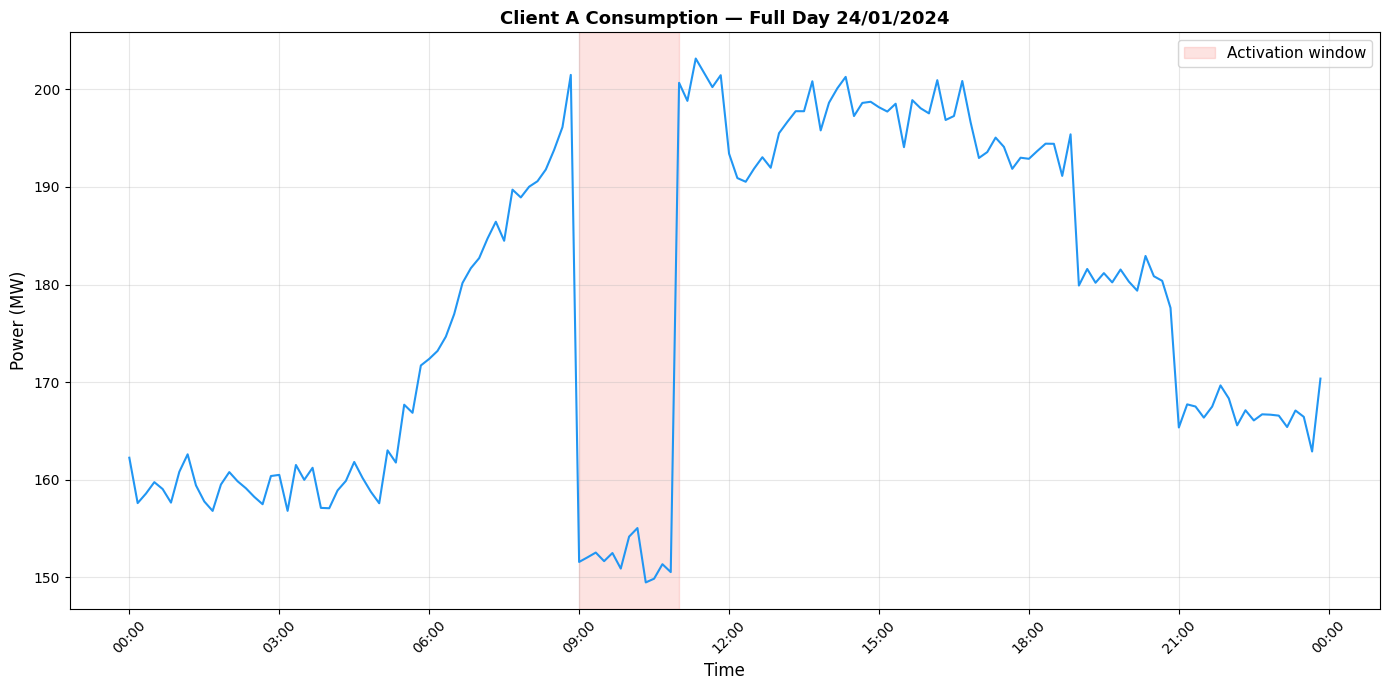

In [31]:
# Full-day consumption on January 24 with the activation window highlighted
df_jour = df[df["date"] == activation_date]

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_jour["Horodate"], df_jour["P Soutiree (kW)"] / 1000,
        color="#2196F3", linewidth=1.5)

# Highlight the activation window
ax.axvspan(activation_start, activation_end, alpha=0.15, color="#F44336",
           label="Activation window")
ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Power (MW)", fontsize=12)
ax.set_title("Client A Consumption — Full Day 24/01/2024", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot2_ClientConsumption.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Full Day Consumption Profile

To better understand the context of the demand response event, I plotted the full consumption curve of Client A on January 24th. This provides a broader view beyond the 2-hour activation window.

The factory follows a typical industrial load pattern: low consumption overnight (~155-160 MW), a ramp-up in the morning as production lines start, and peak consumption during working hours (~195-200 MW). The demand response event is clearly visible as a sharp drop at 09:00, with consumption falling from ~200 MW to ~150 MW, followed by an immediate recovery at 11:00 when the activation ends.

This confirms that the client responded quickly to the curtailment order and resumed normal operations as soon as the activation window closed.

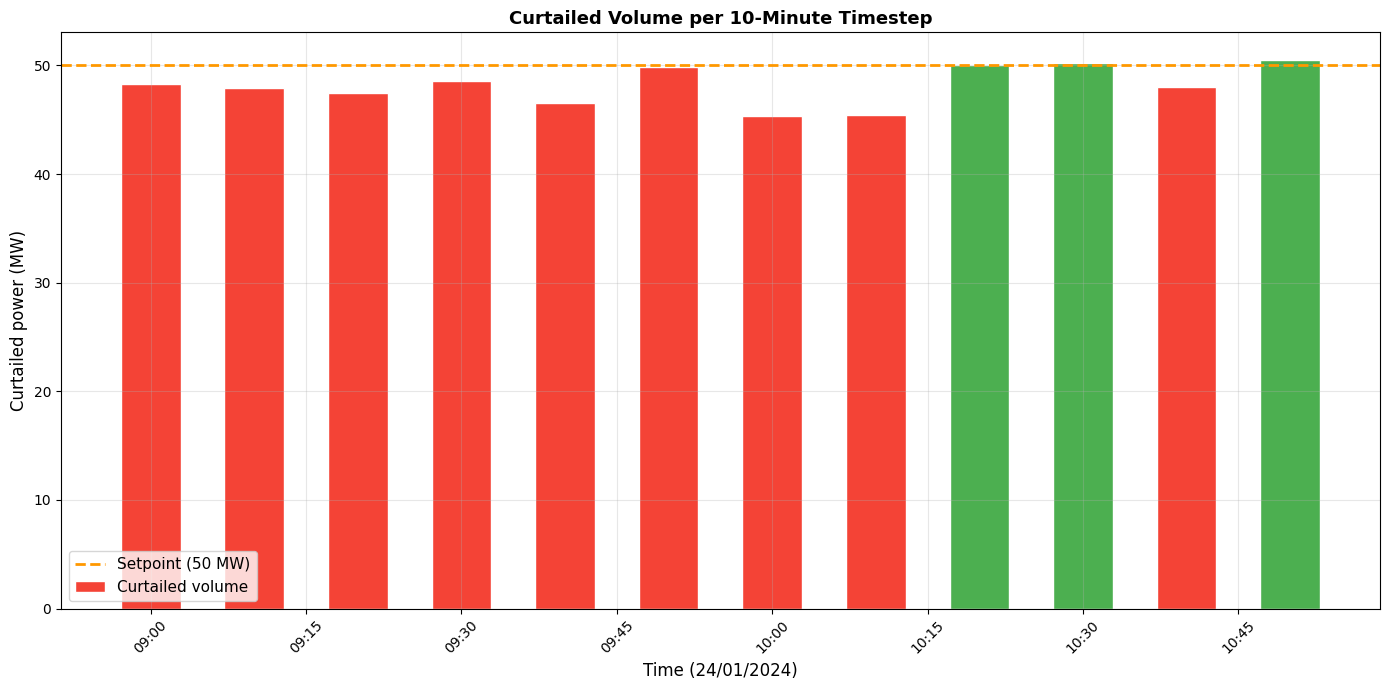

In [30]:
# Bar chart: curtailed power per 10-minute timestep
# Green = met or exceeded setpoint, Red = below setpoint
fig, ax = plt.subplots(figsize=(14, 7))

colors = ["#4CAF50" if v >= consigne_kW else "#F44336"
          for v in df_activation["volume_efface_kW"]]

ax.bar(df_activation["Horodate"], df_activation["volume_efface_kW"] / 1000,
       width=0.004, color=colors, edgecolor="white", label="Curtailed volume")

ax.axhline(y=consigne_MW, color="#FF9800", linewidth=2, linestyle="--",
           label=f"Setpoint ({consigne_MW} MW)")

ax.set_xlabel("Time (24/01/2024)", fontsize=12)
ax.set_ylabel("Curtailed power (MW)", fontsize=12)
ax.set_title("Curtailed Volume per 10-Minute Timestep", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot3_CurtailedVolume.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Curtailed Volume per Timestep

To identify where the client performed well and where it fell short, I broke down the curtailed volume into individual 10-minute timesteps. The orange dashed line represents the 50 MW target.

- **Green bars**: timesteps where the client met or exceeded the curtailment target
- **Red bars**: timesteps where the client fell short of the target

The client slightly under-delivered in the first half of the activation (09:00–10:10), but compensated by over-delivering in the second half (10:20–10:50). This pattern suggests the factory needed some time to fully ramp down its operations.

## 10. Conclusion

The demand response event on January 24th, 2024 (09:00–11:00) was successfully executed. The client curtailed 96.33 MWh out of the 100 MWh expected, achieving a realization rate of 96.3% — well above the 80% compliance threshold. No penalties are applied.

The client earned a total remuneration of 33,715.88 EUR.

The per-timestep analysis reveals that the client needed a few timesteps to reach the full curtailment target, slightly under-delivering in the first hour but compensating in the second hour. This is a common pattern in industrial demand response, as production lines require time to fully ramp down.